In [203]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.svm import SVC

In [204]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [205]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [206]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [207]:
    df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [208]:
# No NA Values

In [209]:
df[df.Churn=='Yes'].shape[0]/df[df.Churn=='No'].shape[0] 

0.36122922303826827

In [210]:
np.dtype(df.TotalCharges)

dtype('O')

In [211]:
#By looking at the above error, we can understand the reason behind the dtype('o')

len(df[df.TotalCharges==' ']) #We have 11 records with Total Charges value -> ' ' and all these rows have Churn value 'NO', let's remove these rows from our analysis (Having information on Churned customers is more important than info on unchurned records)  
df=df[df.TotalCharges!=' ']

df.TotalCharges=pd.to_numeric(df.TotalCharges)
np.dtype(df.TotalCharges)


dtype('float64')

In [212]:
#Ideally SeniorCitizen column should be a factor, so let's convert 1,0 values to Yes,No and later we can label encode all factor columns

df.SeniorCitizen=df.SeniorCitizen.apply(lambda x: 'Yes' if x==1 else 'No')
df.SeniorCitizen.value_counts()

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64

In [213]:
cat_cols_for_wrangling=['MultipleLines','DeviceProtection','OnlineBackup','OnlineSecurity','StreamingMovies','StreamingTV','TechSupport','InternetService']

In [214]:
#Some Data Wrangling.. We will Convert values like 'No Phone Service', 'No Internet Service' to 'No'. In other words, we're creating binary columns (Yes or No)

for col in cat_cols_for_wrangling:
    df[col]=df[col].apply(lambda x: 'No' if 'No' in x else 'Yes')

In [215]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [216]:
cols=df.columns
cols=cols.drop(['customerID','MonthlyCharges','TotalCharges'])
all_cat_cols=list(cols) #All the categorical features that are required for analysis, we'll remove customerID since it's just an ID column with no significance for the analysis

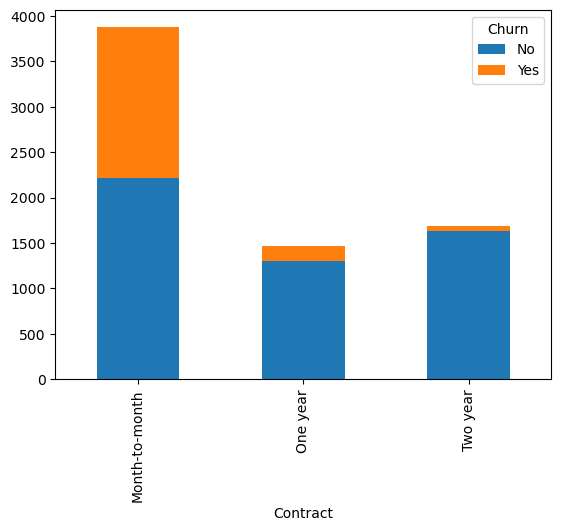

In [217]:
df.groupby(['Contract','Churn']).size().unstack().plot(kind='bar',stacked=True); #Clearly, users with Month-to-Month contract are more likely to churn 

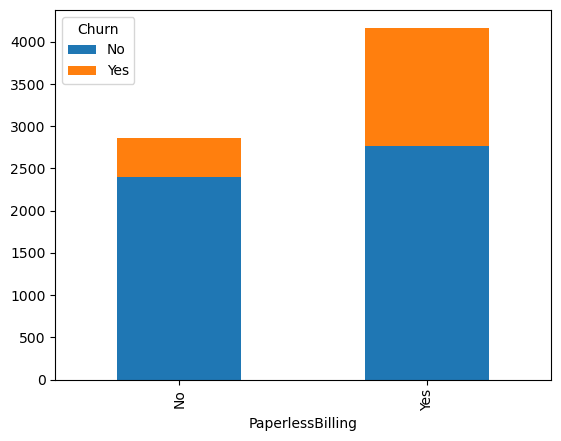

In [218]:
df.groupby(['PaperlessBilling','Churn']).size().unstack().plot(kind='bar',stacked=True);

<Axes: >

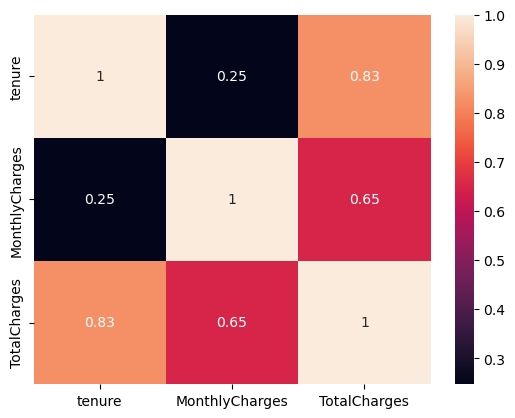

In [219]:
sns.heatmap(
    df.drop('customerID', axis=1)
      .select_dtypes(include='number')
      .corr(),
    annot=True
)

In [220]:
#It makes more sense to categorize customers wrt tenure, so let's convert tenure column to tenure range/buckets

def convert_to_buckets(tenure):
    
    if tenure <=24:
        return '0 - 24 months'
    elif tenure <=36:
        return '24 - 36 months'
    elif tenure <=48:
        return '36 - 48 months'
    elif tenure <=60:
        return '48 - 60 months'
    else:
        return '> 60 months'

In [221]:
df['tenure']=df['tenure'].map(convert_to_buckets)
df['tenure'].value_counts()

tenure
0 - 24 months     3199
> 60 months       1407
24 - 36 months     832
48 - 60 months     832
36 - 48 months     762
Name: count, dtype: int64

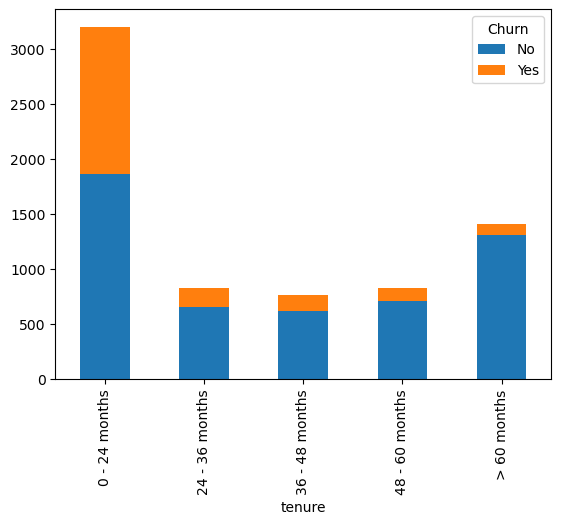

In [222]:
df.groupby(['tenure','Churn']).size().unstack().plot(kind='bar',stacked=True); #customers with 0-24 months tenure are more likely to churn.. 
#From the plot, it is evident that 'tenure' is an important feature as well./

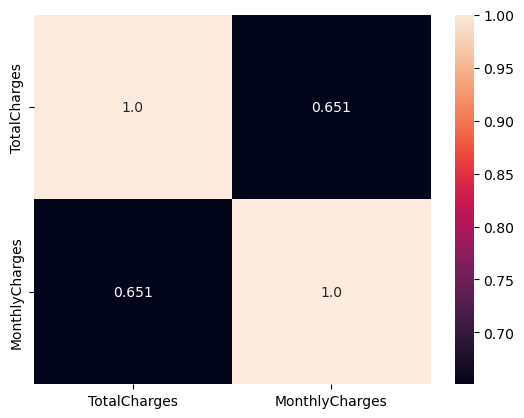

In [223]:
sns.heatmap(df[['TotalCharges','MonthlyCharges']].corr(),annot=True,fmt='.3');
#Since, monthly and Total Charges are corelated.. We'd need to remove one of them, let's remove TotalCharges..

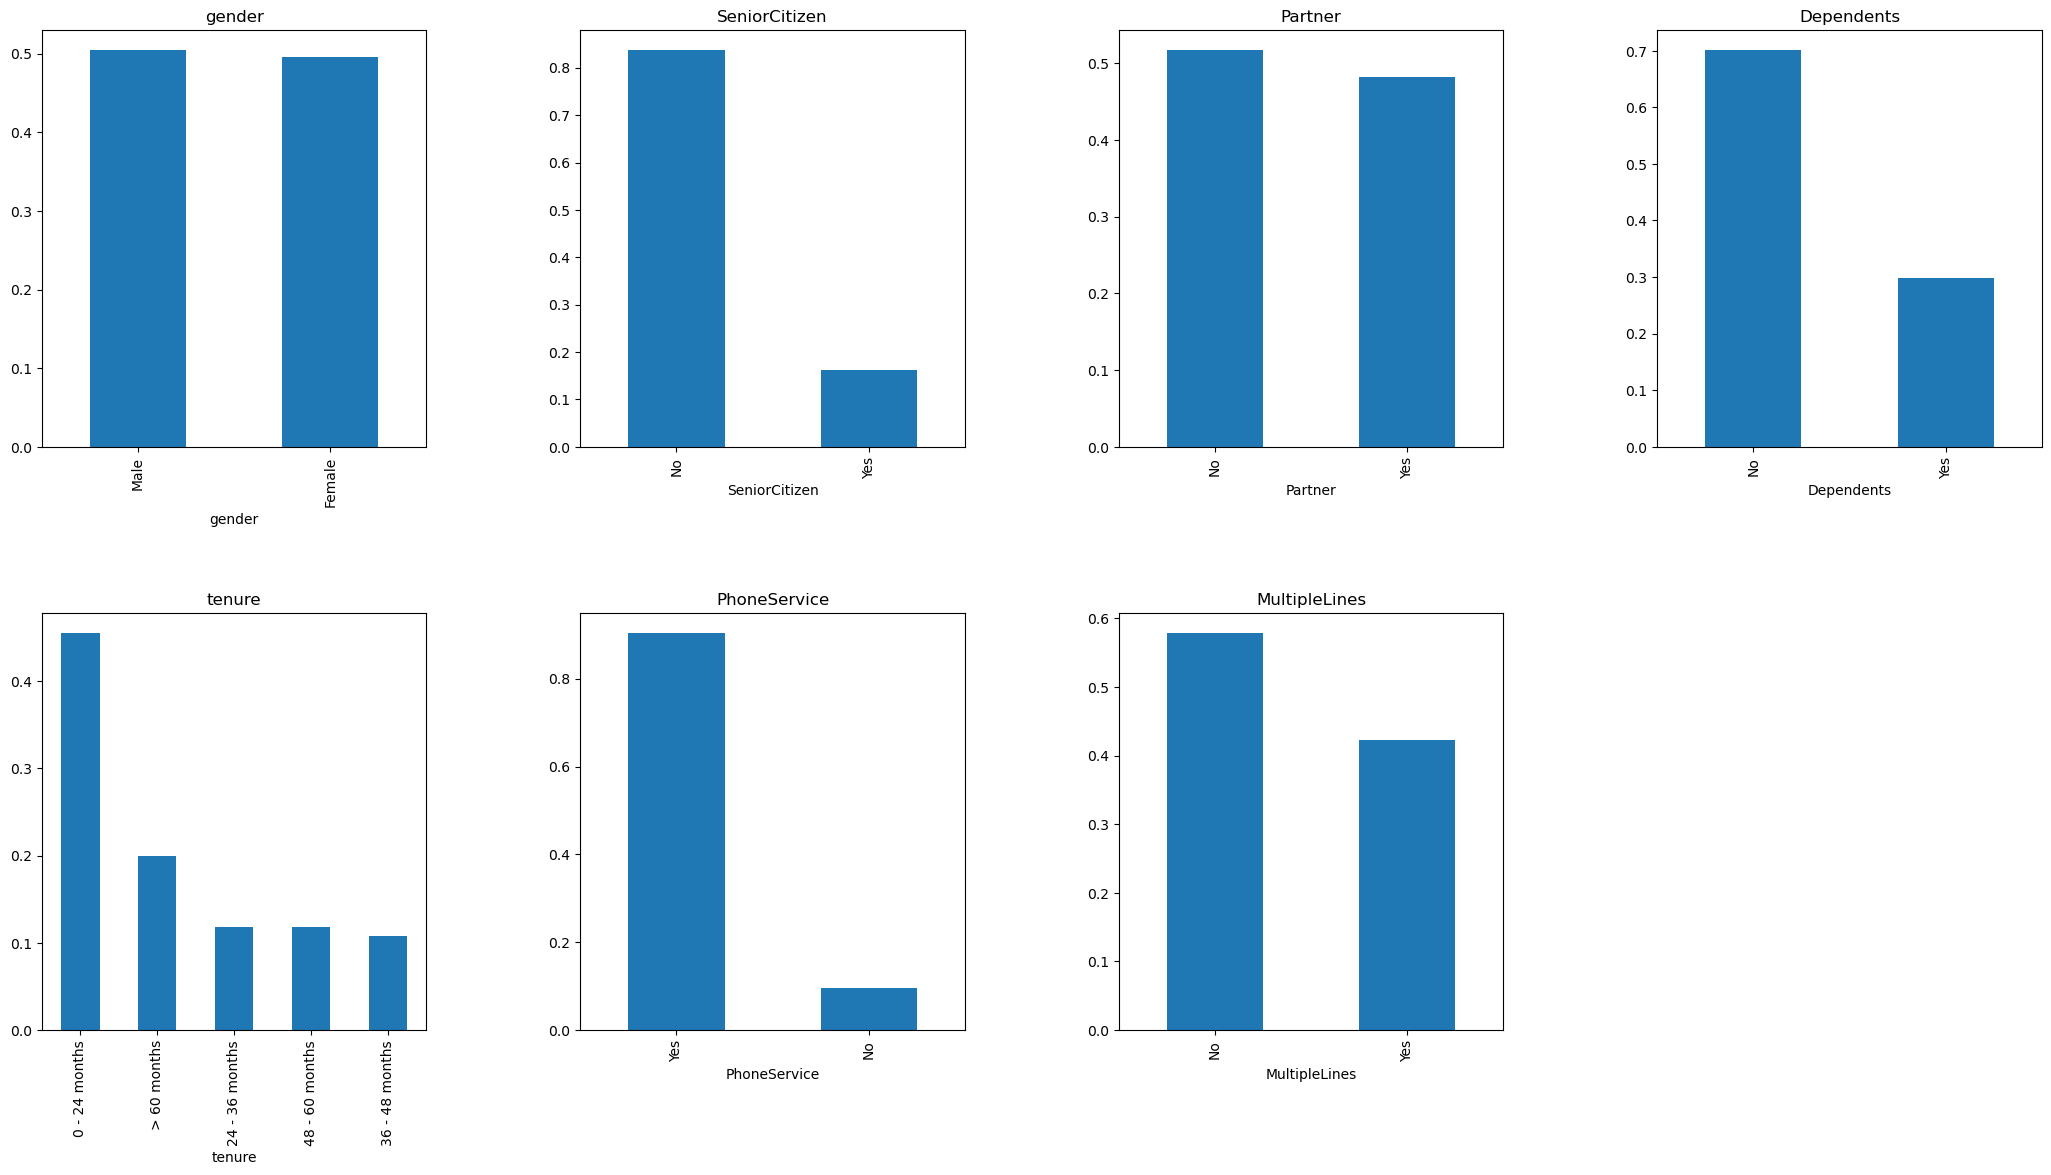

In [224]:

f=plt.figure(figsize=(10,10));
for i in range(7):
    f.add_subplot(2,4,i+1)
    df[all_cat_cols[i]].value_counts(normalize=True).plot(kind='bar',title=all_cat_cols[i])
plt.subplots_adjust(left=3,right=5,top=3,bottom=2,wspace = 0.4,hspace = 0.4)

In [225]:
all_cat_cols #All Categorical column names

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [226]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

for col in all_cat_cols:
    df[col] = labelencoder.fit_transform(df[col])
    

df[all_cat_cols].head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,2,0
1,1,0,0,0,1,1,0,1,1,0,1,0,0,0,1,0,3,0
2,1,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1,3,1
3,1,0,0,0,2,0,0,1,1,0,1,1,0,0,1,0,0,0
4,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1


In [227]:

# TRAIN-TEST SPLIT

In [228]:
#from sklearn.model_selection import train_test_split

X_train=df.sample(frac=0.8,random_state=199)
X_test=df.drop(X_train.index)
len(X_train),len(X_test)

(5626, 1406)

In [229]:
Y_train=X_train['Churn']
Y_test=X_test['Churn']

In [230]:
#Monthly and TotalCharges are corelated, so we remove one of them, we're removing total charges

X_train.drop(columns=['Churn','customerID','TotalCharges'],axis=1,inplace=True)
X_test.drop(columns=['Churn','customerID','TotalCharges'],axis=1,inplace=True)

X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges'],
      dtype='object')

In [231]:
# LOGISTIC REGRESSION

In [232]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

log_model=LogisticRegression(class_weight='balanced')#https://stackoverflow.com/questions/30972029/how-does-the-class-weight-parameter-in-scikit-learn-work
log_model.fit(X_train,Y_train)

Y_pred=log_model.predict(X_test)

C:\Users\ritik\Downloads\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [233]:
accuracy_score(Y_pred,Y_test)

0.7290184921763869

In [234]:
print(classification_report(Y_pred,Y_test))

              precision    recall  f1-score   support

           0       0.71      0.90      0.79       803
           1       0.79      0.50      0.61       603

    accuracy                           0.73      1406
   macro avg       0.75      0.70      0.70      1406
weighted avg       0.74      0.73      0.72      1406



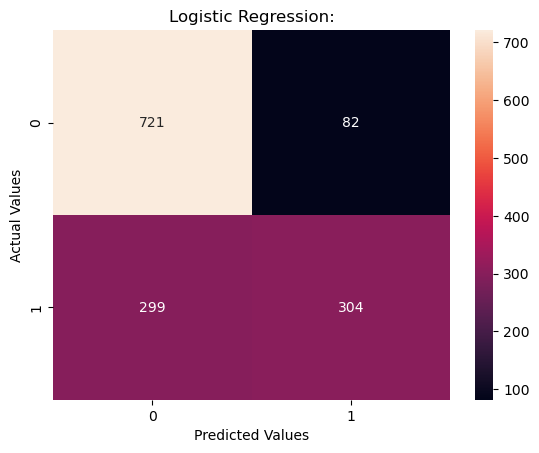

In [236]:
sns.heatmap(confusion_matrix(Y_pred,Y_test),annot=True,fmt='1')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Logistic Regression:'); #';' to exclude printing 'plt' object details 

In [237]:
probs=rf_model.predict_proba(X_test)
Y_rf_probs=[prob[1] for prob in probs]

In [238]:
Y_Pred1={}

for i in range(1,6):
    
    Y_Pred1['0.'+str(15*i)]=pd.Series(Y_rf_probs).apply(lambda x: 1 if x>0.15*i else 0)
    print('Threshold at ','0.'+str(15*i),':\n',classification_report(Y_Pred1['0.'+str(15*i)],Y_test),'\n')


Threshold at  0.15 :
               precision    recall  f1-score   support

           0       0.76      0.98      0.86       789
           1       0.96      0.60      0.74       617

    accuracy                           0.82      1406
   macro avg       0.86      0.79      0.80      1406
weighted avg       0.85      0.82      0.81      1406
 

Threshold at  0.30 :
               precision    recall  f1-score   support

           0       0.92      0.97      0.94       970
           1       0.91      0.81      0.86       436

    accuracy                           0.92      1406
   macro avg       0.92      0.89      0.90      1406
weighted avg       0.92      0.92      0.92      1406
 

Threshold at  0.45 :
               precision    recall  f1-score   support

           0       0.97      0.95      0.96      1038
           1       0.87      0.91      0.89       368

    accuracy                           0.94      1406
   macro avg       0.92      0.93      0.93      1406
weig

In [239]:
# RANDOM FOREST CLASSIFIER

In [240]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier()

In [241]:
rf_model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [242]:
Y_rf_Pred=rf_model.predict(X_test)

In [243]:
print(classification_report(Y_rf_Pred,Y_test))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1127
           1       0.47      0.65      0.54       279

    accuracy                           0.78      1406
   macro avg       0.68      0.73      0.70      1406
weighted avg       0.82      0.78      0.80      1406



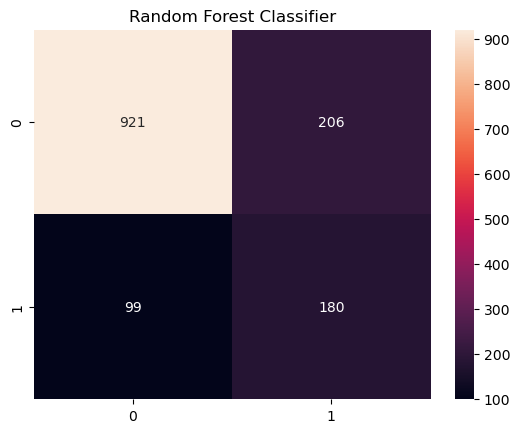

In [244]:
sns.heatmap(confusion_matrix(Y_rf_Pred,Y_test),annot=True,fmt='1')
plt.title('Random Forest Classifier');

In [245]:
probs=rf_model.predict_proba(X_test)
Y_rf_probs=[prob[1] for prob in probs]

In [246]:
#https://stackoverflow.com/questions/49785904/how-to-set-threshold-to-scikit-learn-random-forest-model
Y_Pred1={}

for i in range(1,7):
    
    Y_Pred1['0.'+str(15*i)]=(probs[:,1]>0.15*i).astype('int')
    print('Threshold at ','0.'+str(15*i),':\n',classification_report(Y_Pred1['0.'+str(15*i)],Y_test),'\n')

len(Y_Pred1)


Threshold at  0.15 :
               precision    recall  f1-score   support

           0       0.57      0.91      0.70       643
           1       0.85      0.43      0.57       763

    accuracy                           0.65      1406
   macro avg       0.71      0.67      0.64      1406
weighted avg       0.72      0.65      0.63      1406
 

Threshold at  0.30 :
               precision    recall  f1-score   support

           0       0.77      0.86      0.81       909
           1       0.67      0.52      0.59       497

    accuracy                           0.74      1406
   macro avg       0.72      0.69      0.70      1406
weighted avg       0.73      0.74      0.73      1406
 

Threshold at  0.45 :
               precision    recall  f1-score   support

           0       0.88      0.83      0.86      1086
           1       0.52      0.63      0.57       320

    accuracy                           0.79      1406
   macro avg       0.70      0.73      0.71      1406
weig

6

In [247]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf=GradientBoostingClassifier()
gb_clf.fit(X_train,Y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [248]:
Y_Pred=gb_clf.predict(X_test)

In [249]:
print(classification_report(Y_Pred,Y_test))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1122
           1       0.50      0.68      0.57       284

    accuracy                           0.80      1406
   macro avg       0.70      0.75      0.72      1406
weighted avg       0.83      0.80      0.81      1406



<Axes: >

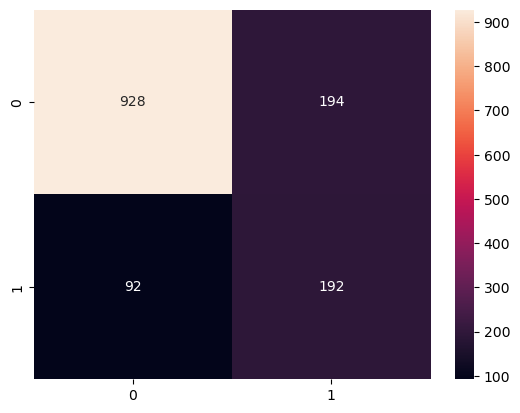

In [250]:
sns.heatmap(confusion_matrix(Y_Pred,Y_test),annot=True,fmt='1')

In [251]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

C:\Users\ritik\Downloads\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


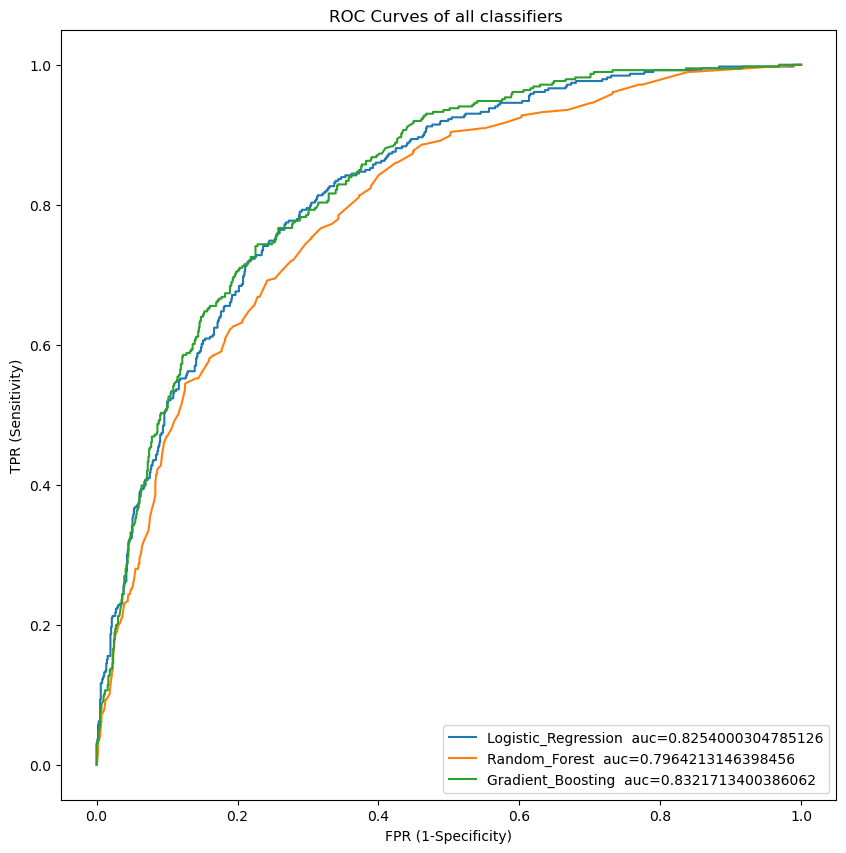

In [252]:
plt.figure(figsize=(10,10));
plt.title('ROC Curves of all classifiers ')
plt.xlabel('FPR (1-Specificity)')
plt.ylabel('TPR (Sensitivity)')
def train_model(clf,X_train,X_test,Y_train):
    
    clf.fit(X_train,Y_train)
    Y_pred,Y_probs=clf.predict(X_test),clf.predict_proba(X_test)[:,1]
    return  Y_pred,Y_probs

clfs={'Logistic_Regression':LogisticRegression(),'Random_Forest':RandomForestClassifier(),'Gradient_Boosting':GradientBoostingClassifier()}
    
for clf_name in clfs.keys():
    
    model =clfs[clf_name]  # select the model
    model.fit(X_train, Y_train)  # train the model
    Y_pred = model.predict(X_test)  # predict the test data
    fpr, tpr, thresholds = roc_curve(Y_test, model.predict_proba(X_test)[:, 1])
    # Calculate Area under the curve to display on the plot
    auc = roc_auc_score(Y_test, 
                          model.predict_proba(X_test)[:,1])
    plt.plot(fpr,tpr,label=clf_name+"  auc="+str(auc));
    plt.legend(loc=4)



In [253]:
#Gradient_Boosting

In [260]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [262]:
from sklearn.ensemble import HistGradientBoostingClassifier
gb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

gb_model.fit(X_train, Y_train)

,loss,'log_loss'
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [263]:
Y_gb_pred = gb_model.predict(X_test)

Y_gb_probs = gb_model.predict_proba(X_test)[:, 1]

In [264]:
print("Accuracy Score:")
print(accuracy_score(Y_test, Y_gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_gb_pred))

print("\nClassification Report:")
print(classification_report(Y_test, Y_gb_pred))

Accuracy Score:
0.786628733997155

Confusion Matrix:
[[911 109]
 [191 195]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1020
           1       0.64      0.51      0.57       386

    accuracy                           0.79      1406
   macro avg       0.73      0.70      0.71      1406
weighted avg       0.78      0.79      0.78      1406



In [258]:
auc_score = roc_auc_score(Y_test, Y_gb_probs)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.832163720410444


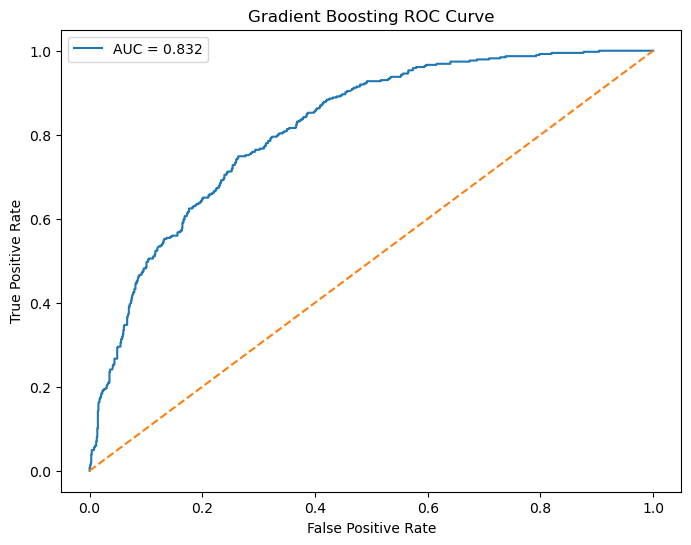

In [266]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_gb_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve")
plt.legend()
plt.show()